## Agenda

1. Feature Scaling
2. Optimal Cluster Selection (Elbow Method)
3. K-Means Clustering Implementation
4. Cluster Visualization (Scatter Plot)
5. Network Technology Distribution
6. Model Evaluation (Silhouette Score)

### 1. Importing Libraries
In this step, we import the necessary libraries for our project. We will use `pandas` for data manipulation, `matplotlib.pyplot` for data visualization, and `KMeans` and `StandardScaler` from `scikit-learn` for clustering and feature scaling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### 2. Loading Data and Selecting Features
We load the pre-processed dataset containing the network data. Then, we select the key performance indicators (KPIs) relevant to network quality: Signal Strength, Data Throughput, and Latency, which will be used for our clustering model.

In [21]:
df = pd.read_csv('processed_data.csv')
features = df[['Signal Strength (dBm)', 'Data Throughput (Mbps)', 'Latency (ms)']]
features.head()

,Signal Strength (dBm),Data Throughput (Mbps),Latency (ms)
0,-84.274113,1.863890,129.122914
1,-97.653121,5.132296,54.883606
2,-87.046134,1.176985,119.598286
3,-94.143159,68.596932,46.598387
4,-94.564765,38.292038,30.342828


### 3. Feature Scaling
Since the features have different scales and units, we apply standard scaling. This ensures that the clustering algorithm does not weigh one feature more than another simply due to its numerical magnitude.

In [3]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### 4. Calculating Inertia for the Elbow Method
To find the optimal number of clusters, we iterate through values of $k$ (from 1 to 10). For each $k$, we train a KMeans model and record its inertia, which measures the compactness of the clusters.

In [4]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

### 5. Visualizing the Elbow Curve
We plot the calculated inertia against the number of clusters. The "elbow" of the curve indicates the optimal $k$, representing a balance between minimizing inertia and preventing overfitting by having too many clusters.

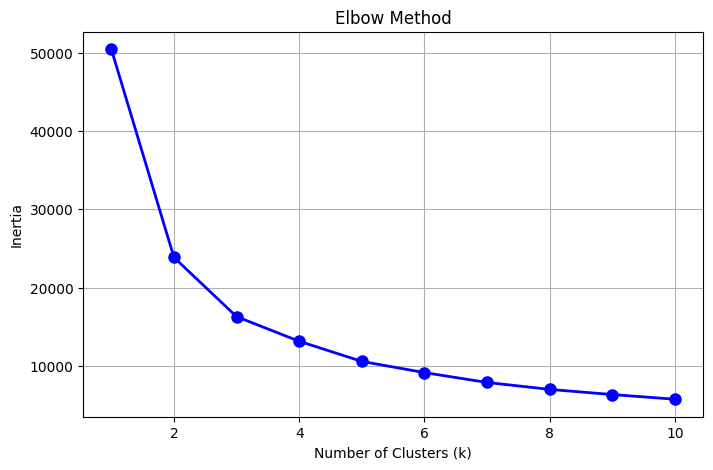

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

### 6. Applying K-Means Clustering and Profiling
Based on the Elbow method, we select k=3 as the optimal number of clusters. We train the KMeans model with 3 clusters and assign a cluster label (0, 1, or 2) to each locality in our dataset. Finally, we calculate the mean values of the network features for each cluster to analyze their specific performance profiles.

In [6]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(scaled_features)
cluster_summary = df.groupby('Cluster')[['Signal Strength (dBm)', 'Data Throughput (Mbps)', 'Latency (ms)']].mean()
cluster_summary

,Signal Strength (dBm),Data Throughput (Mbps),Latency (ms)
Cluster,,,
0,-86.473018,2.123948,153.211366
1,-95.816773,62.976502,29.608220
2,-91.274816,7.560486,77.899620


### 7. Visualizing the Clusters (Scatter Plot)
To clearly see how the algorithm grouped the localities, we create a scatter plot. We will plot 'Signal Strength (dBm)' against 'Data Throughput (Mbps)' and use different colors for each cluster. This simple 2D visualization helps us verify that the model successfully separated the distinct network quality zones.

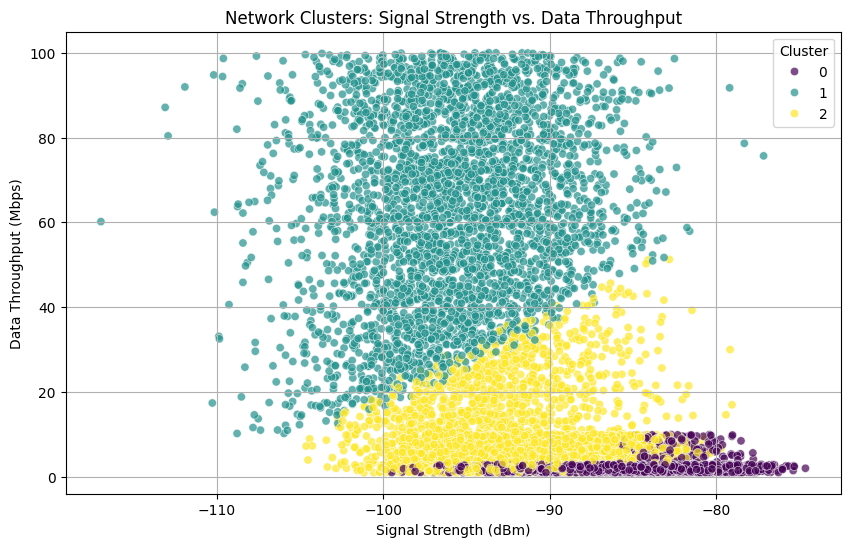

In [7]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Signal Strength (dBm)',
    y='Data Throughput (Mbps)',
    hue='Cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Network Clusters: Signal Strength vs. Data Throughput')
plt.xlabel('Signal Strength (dBm)')
plt.ylabel('Data Throughput (Mbps)')
plt.grid(True)
plt.show()

### 8. Analyzing Network Technologies within Clusters
In this step, we analyze the distribution of different network technologies (3G, 4G, 5G) across our newly formed clusters. By calculating the percentage of each technology within a cluster and visualizing it using a stacked bar chart, we can gain practical engineering insights—such as verifying if high-throughput clusters are predominantly 5G, or if poor-performing clusters are mostly legacy 3G areas.

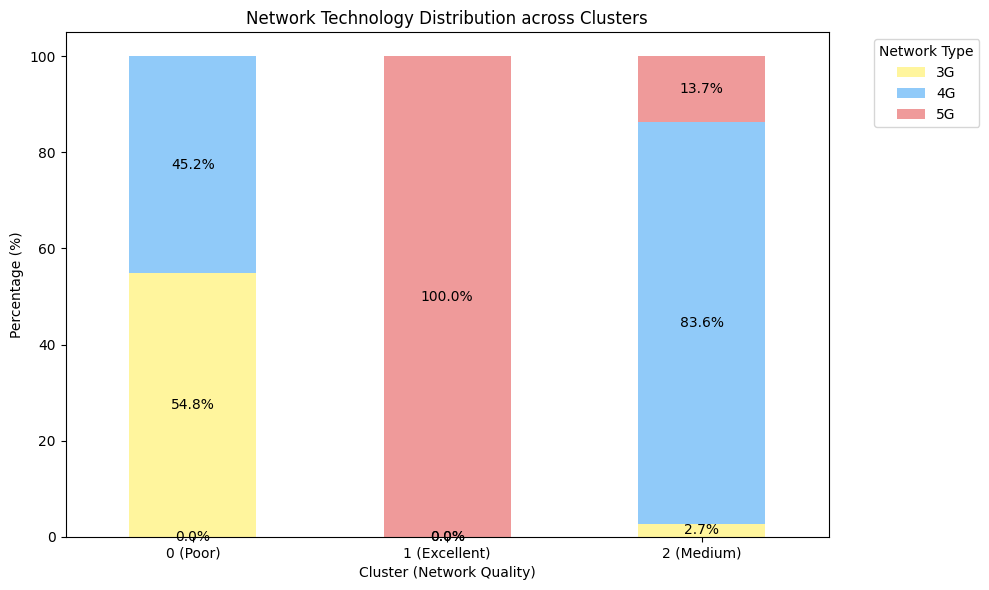

In [11]:
tech_distribution = pd.crosstab(df['Cluster'], df['Network Type'], normalize='index') * 100

cluster_labels = {0: '0 (Poor)', 1: '1 (Excellent)', 2: '2 (Medium)'}
tech_distribution.rename(index=cluster_labels, inplace=True)

ax = tech_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#FFF59D', '#90CAF9', '#EF9A9A'])
plt.title('Network Technology Distribution across Clusters')
plt.xlabel('Cluster (Network Quality)')
plt.ylabel('Percentage (%)')
plt.legend(title='Network Type', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    ax.bar_label(c, label_type='center', fmt='%.1f%%')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9. Clustering Evaluation (Silhouette Score)
Since we are using an Unsupervised Learning approach, typical accuracy metrics are not applicable. Instead, we evaluate the quality of our clustering using the Silhouette Score. This metric, ranging from -1 to 1, measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). A positive score indicates a structurally reasonable and well-defined partitioning of the network data.

In [12]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(scaled_features, df['Cluster'])
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.3906
